# Bidimensional Multivariate EMD (BMEMD)

**BMEMD** extends Multivariate EMD (MEMD) to multi-channel **images**: each
sifting step projects the $n$-channel field onto unit directions on the
$(n-1)$-sphere, finds 2-D extrema of the projected surface, interpolates
multivariate envelopes, and subtracts their mean.

Because every channel yields the **same number of BIMFs at matched scales**,
BMEMD is a natural front-end for multi-scale **image fusion**.

**Reference**

> Y. Xia, B. Zhang, W. Pei, D. P. Mandic.  
> *Bidimensional Multivariate Empirical Mode Decomposition with Applications
in Multi-Scale Image Fusion.* IEEE Access, 7:114261–114270, 2019.

MATLAB codes:  
https://github.com/z-bingo/Bidimensional-Multivariate-Empirical-Mode-Decomposition

This notebook uses the pure PySDKit implementation (`pysdkit.BMEMD`).

## 1. Imports

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "examples":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path and (ROOT / "pysdkit").exists():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import BMEMD
from pysdkit._emd2d.bmemd import local_var_img, fuse_images

print(BMEMD())

Bidimensional Multivariate Empirical Mode Decomposition (BMEMD)


## 2. Algorithm principles

### 2.1 Directional projection (Eq. 4 in the paper)

For a multi-channel image $\{I_\ell\}_{\ell=1}^{n}$ and a unit vector
$u_{\theta_k}$ on the $(n-1)$-sphere,

$$
P_{\theta_k}(i,j) = \sum_{\ell=1}^{n} u_{\theta_k}^{\ell}\, I_\ell(i,j).
$$

- **$n=2$**: uniform samples on the circle  
- **$n\ge 3$**: Hammersley low-discrepancy directions (same idea as MEMD)

### 2.2 Multivariate envelopes

On each $P_{\theta_k}$ find regional maxima / minima (8-neighbour).  At those
pixel locations, sample the **full $n$-channel vector** and interpolate two
surfaces $e^{\max}_{\theta_k}$, $e^{\min}_{\theta_k}$ (Delaunay /
Clough–Tocher).  The mean envelope is

$$
M = \frac{1}{2K}\sum_{k=1}^{K}\big(e^{\max}_{\theta_k}+e^{\min}_{\theta_k}\big).
$$

### 2.3 Sifting & stop criterion

Subtract $M$ until the normalised envelope amplitude map satisfies the MEMD
``stop`` rule (defaults ``sd, sd2, tol = 0.01, 0.1, 0.01``).  The residue is
appended as the last mode.

### 2.4 Fusion (Section IV of the paper)

For each BIMF $q$ and channel $\ell$, compute a local activity map $V^q_\ell$
(squared deviation from a moving mean).  Weights

$$
W^q_\ell = V^q_\ell \,/\, \sum_{\ell'} V^q_{\ell'}
$$

fuse the BIMF; the final image is the sum over scales.

## 3. Synthetic two-channel texture

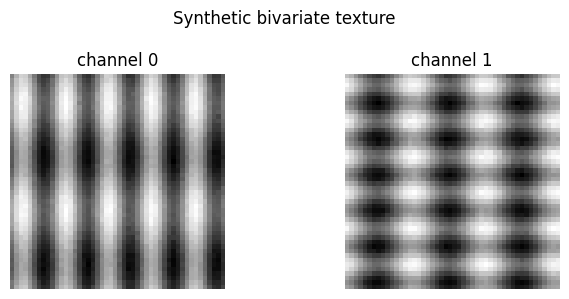

In [2]:
rng = np.random.default_rng(0)
n = 48
yy, xx = np.mgrid[0:n, 0:n]
xx = xx / n
yy = yy / n

ch0 = 0.7 * np.sin(2 * np.pi * 5 * xx) + 0.35 * np.sin(2 * np.pi * 2 * yy)
ch1 = 0.6 * np.cos(2 * np.pi * 3 * xx + 0.5) + 0.4 * np.sin(2 * np.pi * 6 * yy)
ch0 += 0.03 * rng.standard_normal((n, n))
ch1 += 0.03 * rng.standard_normal((n, n))
images = np.stack([ch0, ch1], axis=0)

fig, axes = plt.subplots(1, 2, figsize=(7, 3))
for ax, im, title in zip(axes, images, ["channel 0", "channel 1"]):
    ax.imshow(im, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.suptitle("Synthetic bivariate texture")
plt.tight_layout()
plt.show()

### 3.1 Projection directions & one envelope step

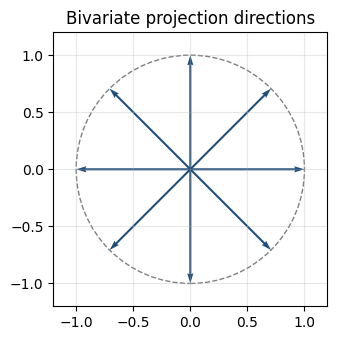

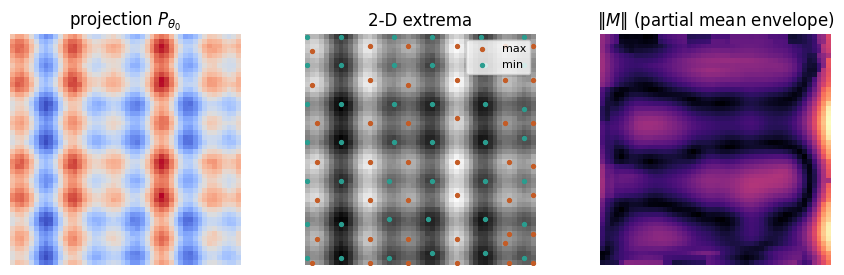

In [3]:
bmemd = BMEMD(n_dir=8, max_imfs=2, max_sift=10)
dirs = bmemd._direction_vectors(2)

fig, ax = plt.subplots(figsize=(3.5, 3.5))
ax.quiver(
    np.zeros(len(dirs)),
    np.zeros(len(dirs)),
    dirs[:, 0],
    dirs[:, 1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="#1f4e79",
)
circ = plt.Circle((0, 0), 1, fill=False, color="0.5", ls="--")
ax.add_patch(circ)
ax.set_aspect("equal")
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_title("Bivariate projection directions")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visualise one projected surface + its extrema
proj = bmemd._project(images, dirs[0])
maxima, minima = bmemd._regional_extrema(proj)

fig, axes = plt.subplots(1, 3, figsize=(9, 2.8))
axes[0].imshow(proj, cmap="coolwarm")
axes[0].set_title(r"projection $P_{\theta_0}$")
axes[1].imshow(proj, cmap="gray")
axes[1].scatter(*np.nonzero(maxima)[::-1], s=8, c="#c45c26", label="max")
axes[1].scatter(*np.nonzero(minima)[::-1], s=8, c="#2a9d8f", label="min")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].set_title("2-D extrema")
env_mean, nem, amp = bmemd._envelope_mean(images, dirs[:4])
axes[2].imshow(np.linalg.norm(env_mean, axis=0), cmap="magma")
axes[2].set_title(r"$\|M\|$ (partial mean envelope)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### 3.2 Full decomposition

IMFs shape: (2, 2, 48, 48)
max |recon error|: 1.1102230246251565e-16


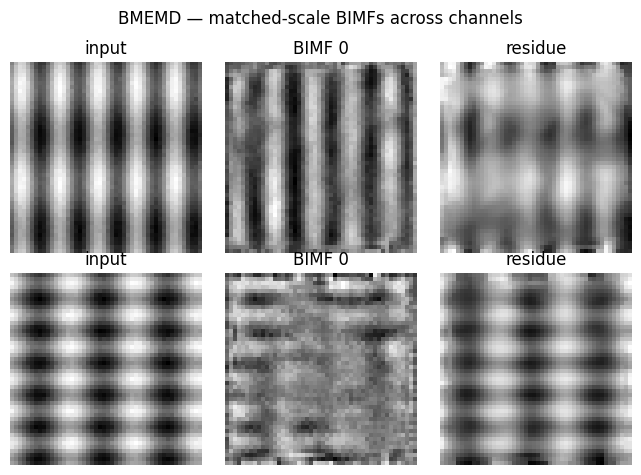

In [4]:
IMFs = bmemd.fit_transform(images)
print("IMFs shape:", IMFs.shape)  # (K, C, H, W)
print("max |recon error|:", np.max(np.abs(IMFs.sum(0) - images)))

K, C = IMFs.shape[0], IMFs.shape[1]
fig, axes = plt.subplots(C, K + 1, figsize=(2.2 * (K + 1), 2.4 * C))
for c in range(C):
    axes[c, 0].imshow(images[c], cmap="gray")
    axes[c, 0].set_ylabel(f"ch {c}")
    axes[c, 0].set_title("input")
    axes[c, 0].axis("off")
    for k in range(K):
        axes[c, k + 1].imshow(IMFs[k, c], cmap="gray")
        axes[c, k + 1].set_title("residue" if k == K - 1 else f"BIMF {k}")
        axes[c, k + 1].axis("off")
plt.suptitle("BMEMD — matched-scale BIMFs across channels")
plt.tight_layout()
plt.show()

## 4. Multi-scale image fusion

We follow the paper / MATLAB ``bmemd_fusion.m`` pipeline on a pair of
complementary source images (downsampled for speed).  Each BIMF is fused with
local-variance weights; the residue uses intensity proportions.

Loaded paper demo images: (2, 64, 64)


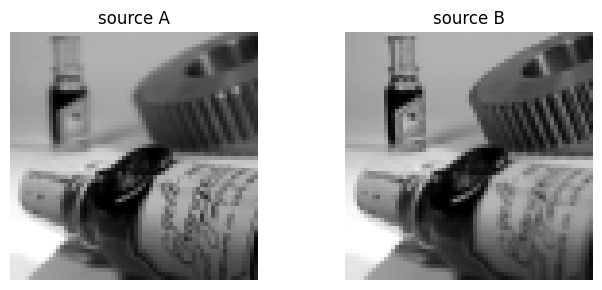

In [5]:
from PIL import Image

img_dir = (
    ROOT / "repo" / "Bidimensional-Multivariate-Empirical-Mode-Decomposition" / "IMG"
)
paths = [img_dir / "source02_1.tif", img_dir / "source02_2.tif"]

if all(p.exists() for p in paths):
    src = []
    for p in paths:
        arr = np.asarray(Image.open(p), dtype=float)
        # downsample for interactive runtime
        arr = np.asarray(
            Image.fromarray(arr.astype(np.uint8)).resize((64, 64), Image.BILINEAR),
            dtype=float,
        )
        src.append(arr / 255.0)
    sources = np.stack(src, axis=0)
    print("Loaded paper demo images:", sources.shape)
else:
    # Fallback: complementary multi-focus style synthetics
    n = 64
    yy, xx = np.mgrid[0:n, 0:n]
    blob = np.exp(-((xx - n * 0.35) ** 2 + (yy - n * 0.5) ** 2) / (2 * 12**2))
    detail = 0.4 * np.sin(2 * np.pi * xx / 5) * np.sin(2 * np.pi * yy / 5)
    a = 0.5 + 0.5 * blob + detail * blob
    b = 0.5 + 0.5 * (1 - blob) + detail * (1 - blob)
    sources = np.stack([a, b], axis=0)
    print("Using synthetic multi-focus pair:", sources.shape)

fig, axes = plt.subplots(1, 2, figsize=(7, 3))
for ax, im, title in zip(axes, sources, ["source A", "source B"]):
    ax.imshow(im, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

BIMFs: (2, 2, 64, 64)


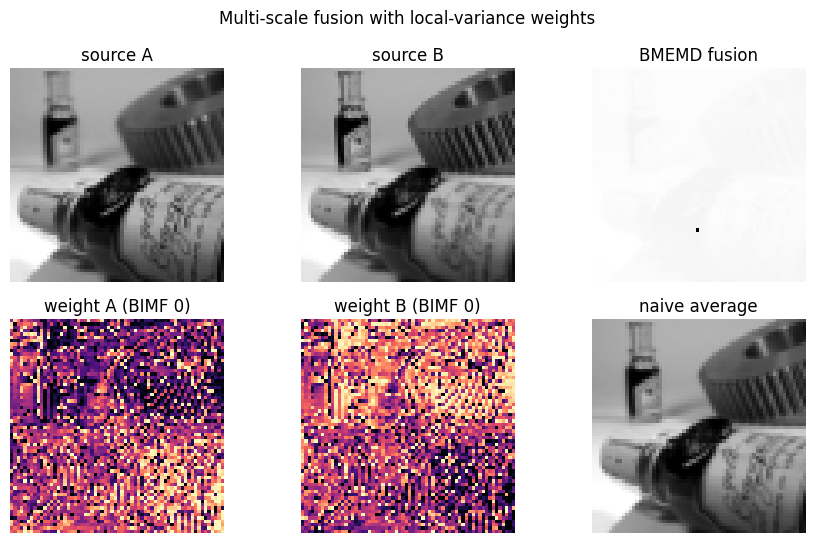

In [6]:
fusion_bmemd = BMEMD(n_dir=8, max_imfs=3, max_sift=12)
imfs_f = fusion_bmemd.fit_transform(sources)
fused = fusion_bmemd.fuse(sources, imfs=imfs_f, var_window=5)

print("BIMFs:", imfs_f.shape)

# Visualise local-variance weights on the first BIMF
var0 = local_var_img(imfs_f[0], window=5)
w0 = var0 / (var0.sum(axis=0, keepdims=True) + 1e-12)

fig, axes = plt.subplots(2, 3, figsize=(9, 5.5))
axes[0, 0].imshow(sources[0], cmap="gray")
axes[0, 0].set_title("source A")
axes[0, 1].imshow(sources[1], cmap="gray")
axes[0, 1].set_title("source B")
axes[0, 2].imshow(fused, cmap="gray")
axes[0, 2].set_title("BMEMD fusion")

axes[1, 0].imshow(w0[0], cmap="magma")
axes[1, 0].set_title("weight A (BIMF 0)")
axes[1, 1].imshow(w0[1], cmap="magma")
axes[1, 1].set_title("weight B (BIMF 0)")
axes[1, 2].imshow(0.5 * (sources[0] + sources[1]), cmap="gray")
axes[1, 2].set_title("naive average")
for ax in axes.ravel():
    ax.axis("off")
plt.suptitle("Multi-scale fusion with local-variance weights")
plt.tight_layout()
plt.show()

### 4.1 Per-scale fused BIMFs

Showing each fused BIMF clarifies that fine detail and coarse structure are
combined separately before reconstruction.

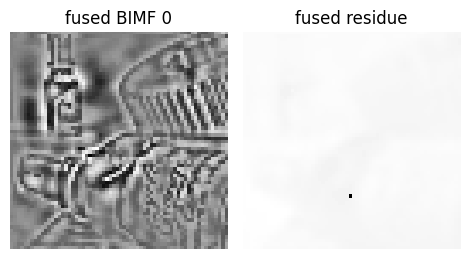

sum of fused scales ≈ fusion: True


In [7]:
K = imfs_f.shape[0]
fused_scales = []
for q in range(K):
    bimf = imfs_f[q]
    if q < K - 1:
        var = local_var_img(bimf, 5)
        w = var / (var.sum(0, keepdims=True) + 1e-12)
    else:
        denom = bimf.sum(0, keepdims=True)
        denom = np.where(np.abs(denom) < 1e-12, 1.0, denom)
        w = bimf / denom
    fused_scales.append(np.sum(bimf * w, axis=0))

fig, axes = plt.subplots(1, K, figsize=(2.4 * K, 2.6))
for k, ax in enumerate(np.atleast_1d(axes)):
    ax.imshow(fused_scales[k], cmap="gray")
    ax.set_title("fused residue" if k == K - 1 else f"fused BIMF {k}")
    ax.axis("off")
plt.tight_layout()
plt.show()

print(
    "sum of fused scales ≈ fusion:",
    np.allclose(np.sum(fused_scales, 0), fused, atol=1e-8),
)

## 5. API summary

```python
from pysdkit import BMEMD

bmemd = BMEMD(n_dir=8, max_imfs=4, stop_crit="stop")
IMFs = bmemd.fit_transform(images)   # images: (C, H, W), C in [2, 16]
# IMFs: (K, C, H, W)  — last mode is the residue

fused = bmemd.fuse(images, imfs=IMFs, var_window=5)
# or: fused, IMFs = fuse_images(images, n_dir=8, max_imfs=3)
```

## 6. Takeaways

- BMEMD = MEMD-style directional sifting on **2-D surfaces**, not vectorised
  pixels.
- Matched BIMF counts across channels enable principled multi-scale fusion.
- Prefer moderate image sizes (or downsample) for interactive work — each
  sifting step fits many Delaunay envelopes.
- Defaults follow the authors’ MATLAB release (`n_dir=8`,
  `stop_vec=[0.01,0.1,0.01]`).